# Curva de tasas nominal de Chile y escenarios de shock de IRRBB

**Pregunta.** ¿Cómo es y cómo se mueve la curva de tasas en pesos de Chile, y cuánto valor pierde una cartera de bonos ante los escenarios de shock que exige Basilea para el riesgo de tasa de interés del libro de banca (IRRBB)?

**Datos.** Base de Datos Estadísticos del Banco Central de Chile, consultada por su API:

- **Swap promedio cámara (SPC) en pesos,** a 90 y 180 días y a 1, 2, 3, 4, 5 y 10 años, diaria desde 2008. Es la curva que usan los bancos chilenos como referencia para valorizar y medir riesgo de tasa.
- **Bonos del Banco Central en pesos (BCP),** tasas de mercado secundario a 2, 5 y 10 años, como comparación soberana.

**Método.** Ajuste diario de Nelson-Siegel, componentes principales de los cambios de la curva, duración y convexidad de bonos, y los seis escenarios estándar de Basilea calibrados para el peso chileno.

**Resultado principal.** La curva de hoy tiene pendiente positiva: va de 4,6% a tres meses a 5,9% a diez años, con la TPM en 4,5%. Desde 2008 estuvo invertida el 18% de los días, con un máximo de 6,2 puntos en enero de 2023. Nelson-Siegel la describe con un error mediano de 4 puntos base, y dos factores, nivel y pendiente, explican el 97% de sus movimientos. En los escenarios de Basilea calibrados para el peso chileno, una cartera de bonos con duración de 4,7 años pierde 10,8% de su valor en el alza paralela. Sin embargo, los movimientos históricos del tramo corto en Chile superan los shocks del método estándar.

## 1. Configuración y datos

In [1]:
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dsaplicado import bcch, datos, tasas
from dsaplicado.graficos import (
    AZUL_SECUENCIAL, COLORES, NEUTRO, TINTA, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo,
)

aplicar_estilo()
pd.set_option("display.float_format", "{:.2f}".format)

RAIZ = datos.raiz_repositorio()
CACHE = RAIZ / "datos" / "bcch"
FIGURAS = RAIZ / "02_finanzas" / "figuras"

SWAP = {"F022.SPC.TPR.D090.NO.Z.D": "0.25", "F022.SPC.TPR.D180.NO.Z.D": "0.5", "F022.SPC.TPR.D360.NO.Z.D": "1",
        "F022.SPC.TIN.AN02.NO.Z.D": "2", "F022.SPC.TIN.AN03.NO.Z.D": "3", "F022.SPC.TIN.AN04.NO.Z.D": "4",
        "F022.SPC.TIN.AN05.NO.Z.D": "5", "F022.SPC.TIN.AN10.NO.Z.D": "10"}
BCP = {"F022.BCLP.TIS.AN02.NO.Z.D": "2", "F022.BCLP.TIS.AN05.NO.Z.D": "5", "F022.BCLP.TIS.AN10.NO.Z.D": "10"}

# Los datos quedan en caché. Solo la primera ejecución consulta la API y requiere el token.
swap = bcch.cargar_series(SWAP, date(2008, 1, 1), date(2026, 9, 23), CACHE / "swap_camara_pesos.csv")
bcp = bcch.cargar_series(BCP, date(2008, 1, 1), date(2026, 9, 23), CACHE / "bcp_mercado_secundario.csv")
tpm = datos.cargar_indicador(RAIZ / "datos" / "tpm_historico.csv", "tpm", range(2001, 2027))
tpm = tpm.mask(tpm < 0.25).ffill()

curva = swap.dropna()
PLAZOS = np.array([float(c) for c in curva.columns])
ETIQUETAS = ["3 meses", "6 meses", "1 año", "2 años", "3 años", "4 años", "5 años", "10 años"]
print(f"Curva swap: {len(curva):,} días completos, de {curva.index[0]:%d-%m-%Y} a {curva.index[-1]:%d-%m-%Y}")

Curva swap: 4,656 días completos, de 02-01-2008 a 23-09-2026


**Convención.** Las tasas swap son tasas de mercado de contratos a cada plazo, no tasas cero cupón puras. Para simplificar, este notebook las trata como una curva de tasas cero y las convierte a capitalización continua para valorizar. Construir la curva cero exacta requiere reconstruirla contrato a contrato con sus convenciones de pago, lo que cambia poco los resultados de sensibilidad pero sí los niveles.

## 2. La curva hoy

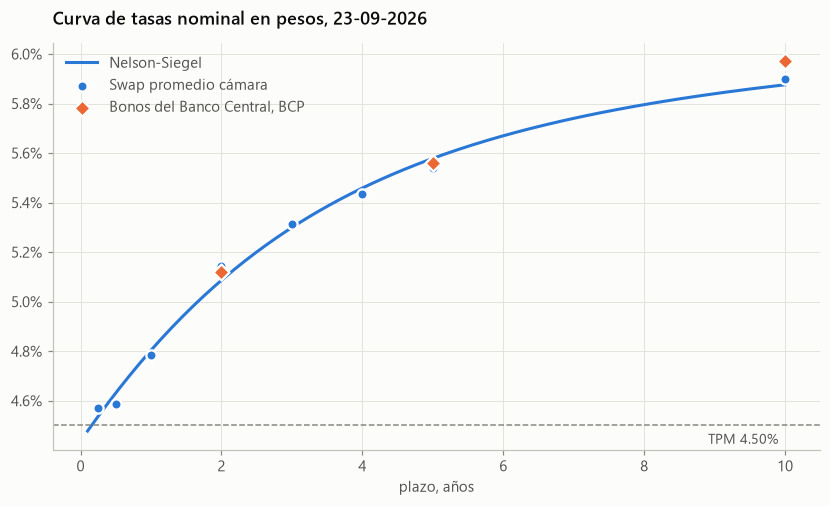

{'nivel': 6.21, 'beta1': -1.77, 'curvatura': -0.65, 'pendiente': 1.77, 'rmse': 0.03}


In [2]:
hoy = curva.index[-1]
ajuste_hoy = tasas.ajustar_nelson_siegel(PLAZOS, curva.iloc[-1].to_numpy())
grilla = np.linspace(0.1, 10, 200)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(grilla, tasas.curva_nelson_siegel(ajuste_hoy, grilla), color=COLORES[0], linewidth=2, label="Nelson-Siegel")
ax.scatter(PLAZOS, curva.iloc[-1], s=45, color=COLORES[0], edgecolor="white", linewidth=1.5, zorder=3,
           label="Swap promedio cámara")
bcp_hoy = bcp.loc[:hoy].ffill().iloc[-1]
ax.scatter([float(c) for c in bcp_hoy.index], bcp_hoy.values, s=55, marker="D", color=COLORES[1], edgecolor="white",
           linewidth=1.5, zorder=3, label="Bonos del Banco Central, BCP")
ax.axhline(tpm.loc[:hoy].iloc[-1], color=TINTA_TENUE, linestyle="--", linewidth=1)
ax.annotate(f"TPM {tpm.loc[:hoy].iloc[-1]:.2f}%", (9.9, tpm.loc[:hoy].iloc[-1]), xytext=(0, -12),
            textcoords="offset points", ha="right", fontsize=9, color=TINTA_SECUNDARIA)
ax.set_xlabel("plazo, años")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_title(f"Curva de tasas nominal en pesos, {hoy:%d-%m-%Y}")
ax.legend(loc="upper left")
fig.savefig(FIGURAS / "curva_tasas_hoy.png", bbox_inches="tight")
plt.show()
print({k: round(v, 2) for k, v in ajuste_hoy.items()})

**Lectura.** La curva sube con el plazo: el tramo corto está cerca de la TPM y el largo casi 1,4 puntos más arriba. Una curva así indica que el mercado no espera recortes importantes de la TPM y exige un premio por plazo. Los bonos del Banco Central cotizan muy cerca de la curva swap, con diferencias de menos de 10 puntos base, así que ambas fuentes cuentan la misma historia. Nelson-Siegel sigue los ocho puntos con un error de 3 puntos base.

## 3. Historia de la curva desde 2008

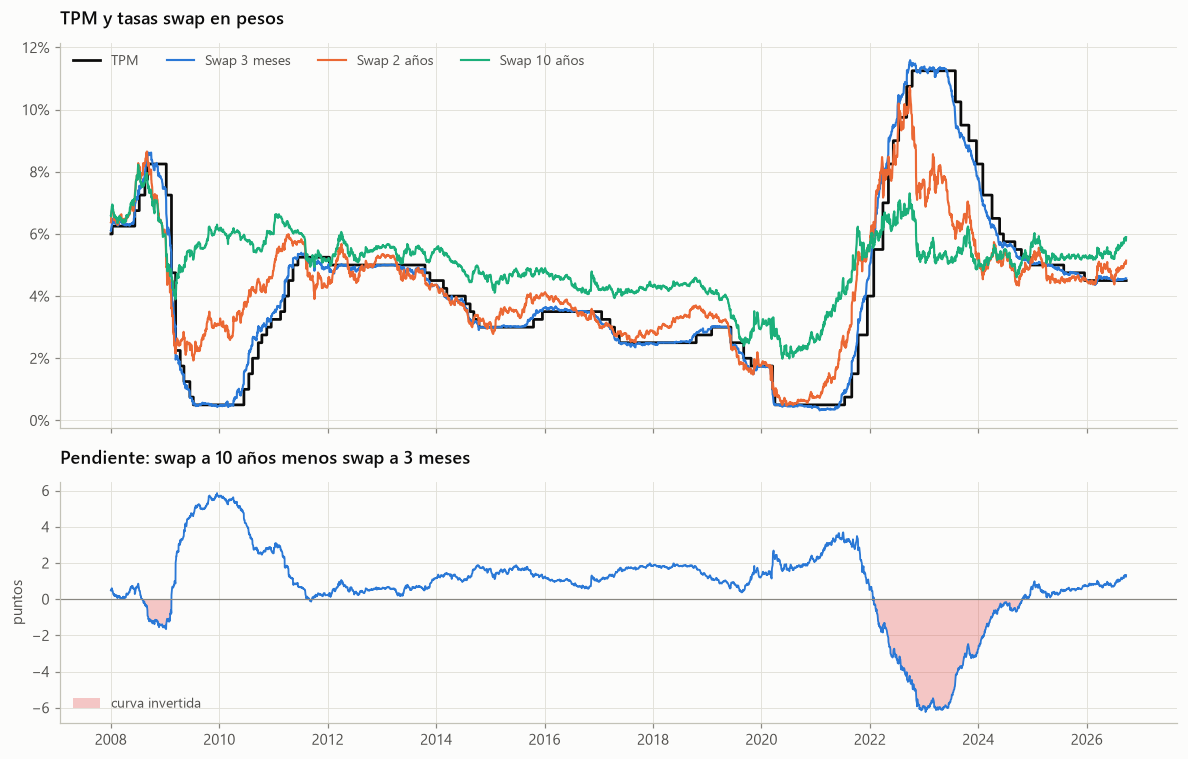

Días con la curva invertida: 18%. Inversión máxima: -6.24 puntos, el 11-01-2023.


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
ax1.step(tpm.loc["2008":].index, tpm.loc["2008":], where="post", color=TINTA, linewidth=1.8, label="TPM")
for columna, nombre, color in [("0.25", "Swap 3 meses", COLORES[0]), ("2", "Swap 2 años", COLORES[1]),
                               ("10", "Swap 10 años", COLORES[2])]:
    ax1.plot(curva.index, curva[columna], color=color, linewidth=1.4, label=nombre)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax1.set_title("TPM y tasas swap en pesos")
ax1.legend(loc="upper left", ncols=4, fontsize=9)

pendiente = curva["10"] - curva["0.25"]
ax2.plot(pendiente.index, pendiente, color=COLORES[0], linewidth=1.2)
ax2.fill_between(pendiente.index, pendiente, 0, where=pendiente < 0, color=COLORES[7], alpha=0.3, linewidth=0,
                 label="curva invertida")
ax2.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax2.set_ylabel("puntos")
ax2.set_title("Pendiente: swap a 10 años menos swap a 3 meses")
ax2.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURAS / "historia_curva.png", bbox_inches="tight")
plt.show()
print(f"Días con la curva invertida: {(pendiente < 0).mean():.0%}. Inversión máxima: {pendiente.min():.2f} puntos, el {pendiente.idxmin():%d-%m-%Y}.")

**Lectura.**

- **El tramo corto sigue a la TPM.** La tasa swap a 3 meses se mueve casi igual que la TPM, anticipando sus cambios por unas semanas.
- **El tramo largo se mueve mucho menos.** Mientras la TPM fue de 0,5% en 2020 a 11,25% en 2022 y 2023, la tasa a 10 años se movió solo entre cerca de 2% y 7%.
- **Dos episodios de inversión.** Uno breve a fines de 2008 y otro profundo entre 2022 y 2024, cuando el mercado anticipaba que la TPM bajaría desde su máximo. En enero de 2023 la tasa a 10 años quedó 6,2 puntos bajo la de 3 meses.

## 4. Nivel, pendiente y curvatura con Nelson-Siegel

Nelson-Siegel resume cada curva en tres números: el **nivel** de las tasas largas, la **pendiente** entre el largo y el corto plazo, y la **curvatura** del tramo medio. Se usa la versión de Diebold y Li, con el parámetro de forma fijo, que hace el ajuste lineal y estable día a día.

Error del ajuste en puntos porcentuales: mediana 0.037, percentil 95 0.195, máximo 0.338 el 15-07-2022


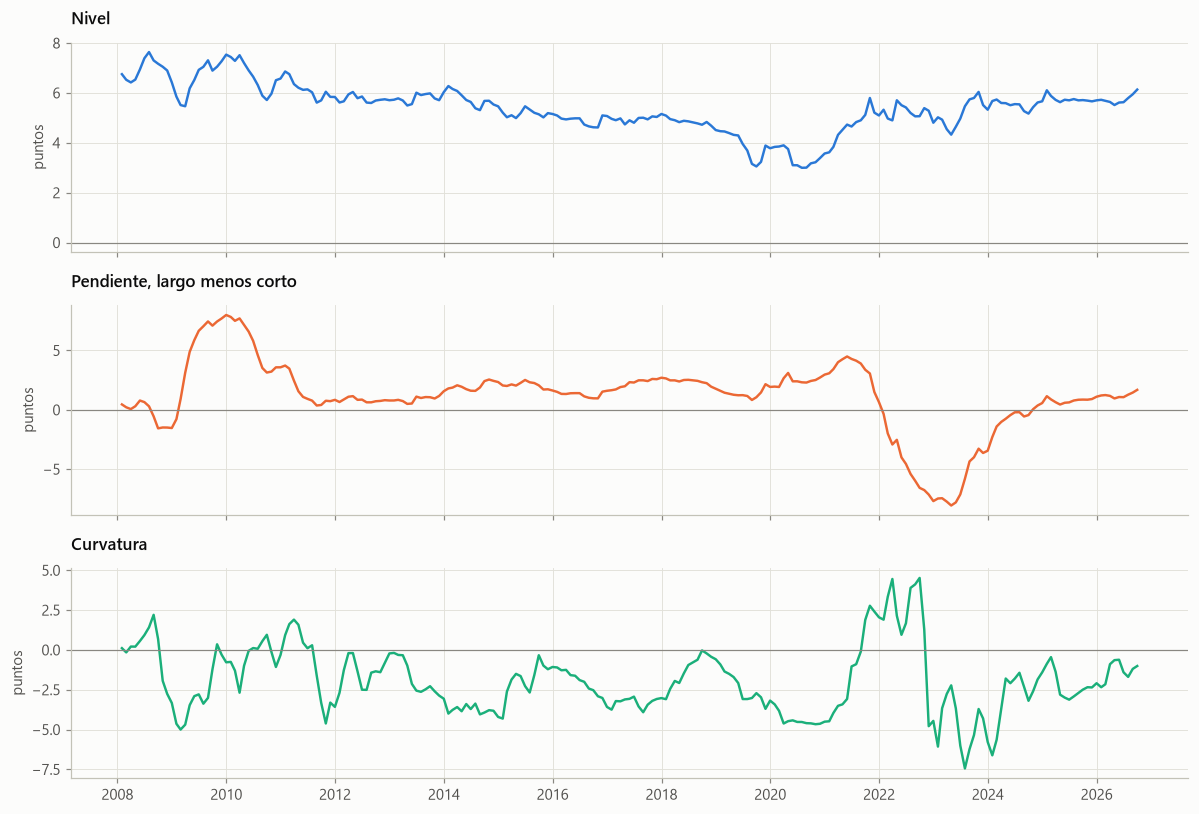

In [4]:
factores = pd.DataFrame([tasas.ajustar_nelson_siegel(PLAZOS, fila.to_numpy()) for _, fila in curva.iterrows()],
                        index=curva.index)
print(f"Error del ajuste en puntos porcentuales: mediana {factores['rmse'].median():.3f}, "
      f"percentil 95 {factores['rmse'].quantile(0.95):.3f}, máximo {factores['rmse'].max():.3f} el {factores['rmse'].idxmax():%d-%m-%Y}")

fig, ejes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
for ax, columna, titulo, color in zip(ejes, ["nivel", "pendiente", "curvatura"],
                                      ["Nivel", "Pendiente, largo menos corto", "Curvatura"], COLORES[:3]):
    mensual = factores[columna].resample("ME").mean()
    ax.plot(mensual.index, mensual, color=color, linewidth=1.6)
    ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel("puntos")
fig.tight_layout()
plt.show()

**Lectura.** El ajuste es muy bueno: la mitad de los días el error es menor a 4 puntos base, y el 95% queda bajo 20 puntos base. El peor ajuste ocurrió en julio de 2022, en plena volatilidad del ciclo de alzas. Los factores resumen la historia: el nivel bajó hasta cerca de 3% en 2020 y volvió a 6%, y la pendiente pasó de casi 8 puntos positivos en 2010 a 8 negativos en 2023.

## 5. ¿Cuántos factores mueven la curva?

Un análisis de componentes principales sobre los cambios mensuales de las ocho tasas muestra cuántas fuentes independientes de movimiento tiene la curva.

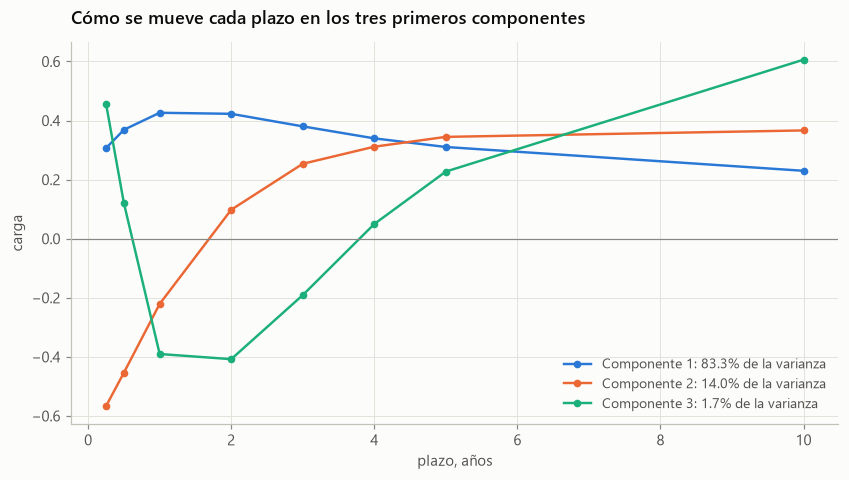

Los dos primeros componentes explican 97.3% y los tres primeros 99.1%.


In [5]:
cambios = curva.resample("ME").last().diff().dropna()
valores, vectores = np.linalg.eigh(np.cov(cambios.to_numpy().T))
orden = np.argsort(valores)[::-1]
valores, vectores = valores[orden], vectores[:, orden]
explicada = valores / valores.sum()
# Signo de cada componente para que el nivel sea positivo y la pendiente suba con el plazo.
vectores[:, 0] *= np.sign(vectores[:, 0].sum())
vectores[:, 1] *= np.sign(vectores[-1, 1] - vectores[0, 1])
vectores[:, 2] *= np.sign(vectores[-1, 2])

fig, ax = plt.subplots(figsize=(9, 4.5))
for k, nombre in enumerate(["Componente 1", "Componente 2", "Componente 3"]):
    ax.plot(PLAZOS, vectores[:, k], marker="o", markersize=4, color=COLORES[k],
            label=f"{nombre}: {explicada[k]:.1%} de la varianza")
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_xlabel("plazo, años")
ax.set_ylabel("carga")
ax.set_title("Cómo se mueve cada plazo en los tres primeros componentes")
ax.legend(loc="lower right", fontsize=9)
plt.show()
print(f"Los dos primeros componentes explican {explicada[:2].sum():.1%} y los tres primeros {explicada[:3].sum():.1%}.")

**Lectura.**

- **El primer componente, 83% de la varianza, mueve todas las tasas en la misma dirección.** No es un desplazamiento paralelo puro: los plazos de 1 y 2 años se mueven casi el doble que el de 10 años. En Chile el nivel de la curva lo empuja la política monetaria, que pega más fuerte en el tramo corto y medio.
- **El segundo componente, 14%, es la pendiente.** Sube el largo y baja el corto, o al revés.
- **El tercero, menos de 2%, es la curvatura.** Mueve el tramo medio contra los extremos.

Con dos componentes se explica el 97% de los movimientos. Por eso los escenarios de IRRBB se construyen con desplazamientos paralelos y cambios de pendiente.

## 6. Duración y convexidad

Se valoriza una cartera ilustrativa de tres bonos bullet con cupón semestral de 5% anual, a 2, 5 y 10 años, con nominal 100 cada uno, descontados con la curva de hoy.

In [6]:
BONOS = {"Bono 2 años": 2, "Bono 5 años": 5, "Bono 10 años": 10}
CUPON = 5.0

def tasas_cero(parametros, tiempos):
    # Tasa anual de la curva convertida a capitalización continua.
    return np.log1p(tasas.curva_nelson_siegel(parametros, tiempos) / 100) * 100

cartera = {}
filas = {}
for nombre, plazo in BONOS.items():
    tiempos, montos = tasas.flujos_bono(CUPON, plazo)
    cero = tasas_cero(ajuste_hoy, tiempos)
    cartera[nombre] = (tiempos, montos, cero)
    filas[nombre] = tasas.duracion_convexidad(tiempos, montos, cero)
tabla_bonos = pd.DataFrame(filas).T
tabla_bonos.loc["Cartera", "precio"] = tabla_bonos["precio"].sum()
pesos = tabla_bonos.loc[list(BONOS), "precio"] / tabla_bonos.loc["Cartera", "precio"]
tabla_bonos.loc["Cartera", "duracion"] = (pesos * tabla_bonos.loc[list(BONOS), "duracion"]).sum()
tabla_bonos.loc["Cartera", "convexidad"] = (pesos * tabla_bonos.loc[list(BONOS), "convexidad"]).sum()
tabla_bonos

,precio,duracion,convexidad
Bono 2 años,99.97,1.93,3.80
Bono 5 años,97.96,4.48,21.45
Bono 10 años,94.46,7.90,72.23
Cartera,292.39,4.71,31.82


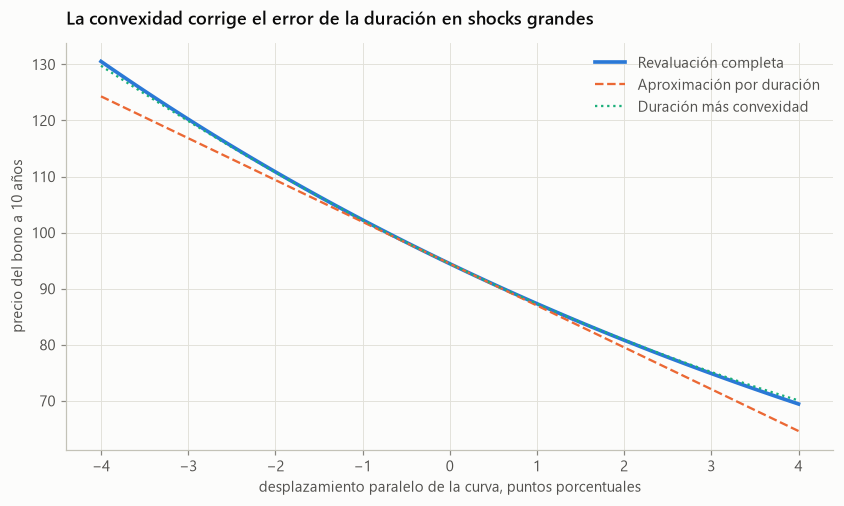

In [7]:
tiempos, montos, cero = cartera["Bono 10 años"]
base = tabla_bonos.loc["Bono 10 años"]
desplazamientos = np.linspace(-4, 4, 81)
exacto = [tasas.precio_con_curva(tiempos, montos, cero + d) for d in desplazamientos]
solo_duracion = base["precio"] * (1 - base["duracion"] * desplazamientos / 100)
con_convexidad = solo_duracion + base["precio"] * 0.5 * base["convexidad"] * (desplazamientos / 100) ** 2

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(desplazamientos, exacto, color=COLORES[0], linewidth=2.4, label="Revaluación completa")
ax.plot(desplazamientos, solo_duracion, color=COLORES[1], linewidth=1.5, linestyle="--", label="Aproximación por duración")
ax.plot(desplazamientos, con_convexidad, color=COLORES[2], linewidth=1.5, linestyle=":", label="Duración más convexidad")
ax.set_xlabel("desplazamiento paralelo de la curva, puntos porcentuales")
ax.set_ylabel("precio del bono a 10 años")
ax.set_title("La convexidad corrige el error de la duración en shocks grandes")
ax.legend(loc="upper right")
plt.show()

La duración aproxima bien los cambios chicos, pero subestima el precio en ambos sentidos cuando el shock es grande, porque la relación entre precio y tasa es curva. Agregar la convexidad corrige casi todo el error, incluso con shocks de 4 puntos.

## 7. Escenarios de shock de Basilea para IRRBB

El estándar de Basilea para IRRBB define seis escenarios: alza y baja paralela, empinamiento, aplanamiento, y alza y baja del tramo corto. Los tamaños de cada shock se calibran por moneda multiplicando la tasa promedio histórica por 60% para el shock paralelo, 85% para el corto y 40% para el largo, y redondeando a 50 puntos base. Aquí se aplica ese método a la curva swap del peso chileno entre 2008 y 2026.

In [8]:
tasa_promedio = curva.to_numpy().mean()
redondear = lambda x: round(x * 2) / 2
SHOCK_PARALELO, SHOCK_CORTO, SHOCK_LARGO = (redondear(f * tasa_promedio) for f in (0.60, 0.85, 0.40))
print(f"Tasa promedio de la curva: {tasa_promedio:.2f}%")
print(f"Shocks calibrados: paralelo {SHOCK_PARALELO:.1f}, corto {SHOCK_CORTO:.1f} y largo {SHOCK_LARGO:.1f} puntos porcentuales")

cambios_6m = curva.resample("ME").last().diff(6).dropna()
historico = cambios_6m.abs().quantile(0.99)
print("\nPercentil 99 de los cambios a seis meses observados, por plazo:")
print(historico.rename(dict(zip(curva.columns, ETIQUETAS))).round(2).to_string())

Tasa promedio de la curva: 4.41%
Shocks calibrados: paralelo 2.5, corto 3.5 y largo 2.0 puntos porcentuales

Percentil 99 de los cambios a seis meses observados, por plazo:
3 meses   6.68
6 meses   6.50
1 año     6.00
2 años    4.52
3 años    3.66
4 años    3.17
5 años    2.90
10 años   2.51


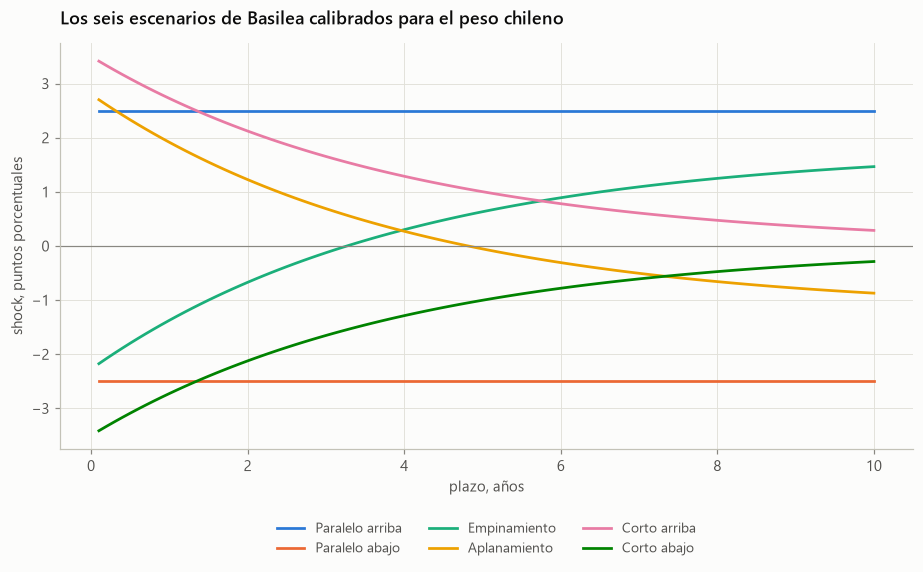

In [9]:
grilla_esc = np.linspace(0.1, 10, 100)
formas = tasas.escenarios_basilea(grilla_esc, SHOCK_PARALELO, SHOCK_CORTO, SHOCK_LARGO)
fig, ax = plt.subplots(figsize=(10, 4.8))
for k, escenario in enumerate(formas.columns):
    ax.plot(formas.index, formas[escenario], color=COLORES[k], linewidth=1.8, label=escenario.capitalize())
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_xlabel("plazo, años")
ax.set_ylabel("shock, puntos porcentuales")
ax.set_title("Los seis escenarios de Basilea calibrados para el peso chileno")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=3, fontsize=9)
plt.show()

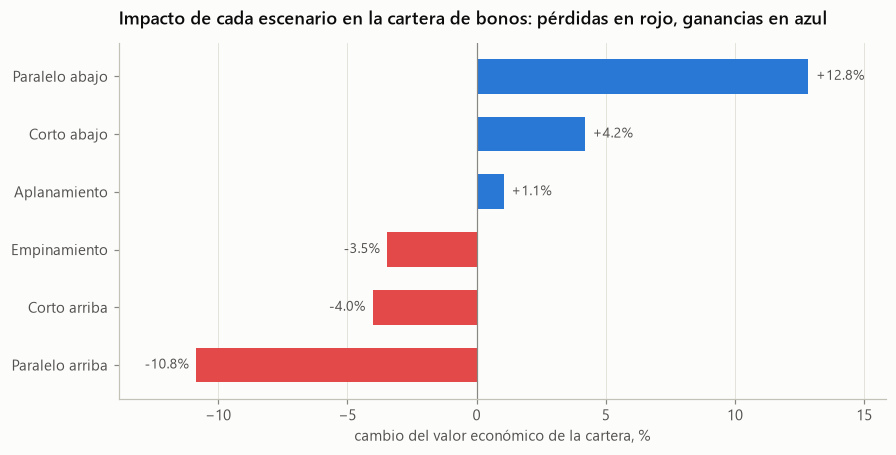

,cambio de valor,% del valor
paralelo arriba,-31.71,-10.85
paralelo abajo,37.55,12.84
empinamiento,-10.10,-3.46
aplanamiento,3.08,1.05
corto arriba,-11.76,-4.02
corto abajo,12.27,4.20


In [10]:
valor_base = tabla_bonos.loc["Cartera", "precio"]
impacto = {}
for escenario in formas.columns:
    valor = 0.0
    for tiempos, montos, cero in cartera.values():
        shock = tasas.escenarios_basilea(tiempos, SHOCK_PARALELO, SHOCK_CORTO, SHOCK_LARGO)[escenario].to_numpy()
        valor += tasas.precio_con_curva(tiempos, montos, cero + shock)
    impacto[escenario] = valor - valor_base
impacto = pd.Series(impacto).rename("cambio de valor")
resultado = pd.DataFrame({"cambio de valor": impacto, "% del valor": 100 * impacto / valor_base})

fig, ax = plt.subplots(figsize=(9, 4.2))
orden_esc = resultado["cambio de valor"].sort_values().index
colores = [COLORES[7] if v < 0 else COLORES[0] for v in resultado.loc[orden_esc, "cambio de valor"]]
ax.barh([e.capitalize() for e in orden_esc], resultado.loc[orden_esc, "% del valor"], color=colores, height=0.6)
for i, v in enumerate(resultado.loc[orden_esc, "% del valor"]):
    ax.annotate(f"{v:+.1f}%", (v, i), xytext=(5 if v >= 0 else -5, 0), textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=9, color=TINTA_SECUNDARIA)
ax.axvline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_xlim(resultado["% del valor"].min() - 3, resultado["% del valor"].max() + 3)
ax.set_xlabel("cambio del valor económico de la cartera, %")
ax.set_title("Impacto de cada escenario en la cartera de bonos: pérdidas en rojo, ganancias en azul")
ax.grid(axis="y", visible=False)
fig.savefig(FIGURAS / "escenarios_irrbb.png", bbox_inches="tight")
plt.show()
resultado

**Lectura.**

- **El alza paralela es el peor escenario para esta cartera.** Pierde 10,8% de su valor, algo menos que lo que predice la duración de 4,7 años, gracias a la convexidad.
- **La asimetría viene de la convexidad.** La baja paralela gana 12,8%, más de lo que pierde el alza del mismo tamaño.
- **El empinamiento también pierde,** porque sube el tramo largo, donde está el bono con más duración.
- **Los shocks del método estándar se quedan cortos en el tramo corto.** El percentil 99 de los cambios históricos a seis meses supera los 6 puntos en los plazos de hasta un año, casi el doble del shock corto calibrado. En los plazos largos, el shock calibrado y la historia coinciden. Para el peso chileno conviene complementar los escenarios de Basilea con pruebas de estrés históricas, como el ciclo de 2021 y 2022.

## 8. Conclusiones

1. **La curva de tasas en pesos se describe bien con tres factores.** Nelson-Siegel la ajusta con errores de pocos puntos base, y nivel y pendiente explican el 97% de sus movimientos.
2. **La política monetaria domina el tramo corto.** Los grandes movimientos se concentran hasta 2 años, y la curva se invirtió con fuerza cuando la TPM llegó a su máximo.
3. **La duración mide el riesgo, la convexidad lo corrige.** Para shocks del tamaño que exige Basilea, ignorar la convexidad sobrestima las pérdidas.
4. **Los escenarios estándar no bastan en Chile.** Los movimientos históricos del tramo corto superan los shocks calibrados, así que un análisis de IRRBB para bancos chilenos debería incluir estrés histórico.

## 9. Limitaciones y extensiones

- **Tasas swap como curva cero.** La curva se usa tal como se cotiza. Una curva cero construida contrato a contrato daría niveles algo distintos.
- **Solo hasta 10 años.** El swap en pesos no tiene plazos más largos en esta fuente. Los pasivos y activos de más de 10 años requerirían extrapolar la curva.
- **Cartera ilustrativa.** Un análisis de IRRBB real mide el cambio del valor económico de todo el balance del banco, incluidos los depósitos con los supuestos de beta del notebook anterior. Ese análisis es el objetivo del repositorio dedicado a IRRBB y ALM.
- **Calibración propia.** Los shocks siguen el método del estándar, pero con la historia chilena desde 2008. No reemplazan los valores que fije el regulador.